Here we will test the algorithm of Douglas-Peucker without pymeos then with pymeos.

import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm
import contextily as cx
from pymeos.db.psycopg import MobilityDB
from shapely.geometry import Point

from geopandas import GeoDataFrame, read_file

import sys
sys.path.append("..")
import movingpandas as mpd

import warnings
warnings.simplefilter("ignore")
import pymeos
from pymeos.mixins.simplify import TSimplifiable
from pymeos import TGeomPointSeq, TGeomPointInst
pymeos.pymeos_initialize()



In [30]:
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm
# import contextily as cx
from pymeos.db.psycopg import MobilityDB
from shapely.geometry import Point

from geopandas import GeoDataFrame, read_file

import sys
sys.path.append("..")
import movingpandas as mpd

import warnings
import numpy as np
warnings.simplefilter("ignore")
import pymeos
from pymeos.mixins.simplify import TSimplifiable
from pymeos import TGeogPointSeq, TGeogPointInst
pymeos.pymeos_initialize()



In [31]:
host = "localhost"
port = 5432
db = "test"
user = "postgres"
password = "Guynemer?6"

connection = MobilityDB.connect(
    host=host, port=port, dbname=db, user=user, password=password
)
cursor = connection.cursor()

sizes = {'small': 100000, 'medium': 1000000, 'big': 10000000}
chosen_size = 'small'

# flights data
### without pymeos

In [32]:
# %%timeit
def extraction():
    cursor.execute(f"SELECT etts, icao24, lat, lon FROM public.flightsinput limit {sizes[chosen_size]};")
    rows = cursor.fetchall() # il y a 3980 avions, 706609 points
    global df
    df = pd.DataFrame(rows, columns=['t', 'icao24', 'lat', 'lon'])
    df = df.drop_duplicates(subset=['t', 'icao24'], keep='first')
    global nb_points
    nb_points = df.shape[0]

In [33]:
# %%timeit
def construction_without():
    df1 = df.copy()
    df1['geometry'] = [Point(lon, lat) for lon, lat in zip(df1['lon'], df1['lat'])]
    gdf = GeoDataFrame(df1, geometry='geometry')
    gdf.set_crs(epsg=4326, inplace=True)
    gdf['t'] = pd.to_datetime(gdf['t'])
    # gdf = gdf.sort_values(['icao24', 't'])
    # gdf = gdf.drop_duplicates(subset=['icao24', 't'], keep='first')
    gdf.set_index('t', inplace=True)
    gdf = gdf.drop(columns=['lat', 'lon'])

    global trajectories_without
    trajectories_without = mpd.TrajectoryCollection(gdf, traj_id_col='icao24')

# construction_without()

In [34]:
# %%timeit
def simplify_without():
    global simplified_without
    simplified_without = mpd.DouglasPeuckerGeneralizer(trajectories_without).generalize(tolerance=0.0001)

# 67 s

# simplify_without()

### with pymeos

In [44]:
# %%timeit
# Method 1

def construction_from_instants():

    df2 = df.sort_values(['icao24', 't'])
    df2['geometry'] = [Point(lon, lat) for lon, lat in zip(df2['lon'], df2['lat'])]
    gdf2 = GeoDataFrame(df2, geometry='geometry')
    gdf2.set_crs(epsg=4326, inplace=True)

    # 93.5 ms

    srid = 4326
    gdf2["point"] = gdf2.apply(
        lambda row: TGeogPointInst(
            point=row["geometry"],
            timestamp=row["t"],
            srid=srid,
        ),
        axis=1,
    )

    # 15 ms
    global trajectories_with2
    trajectories_with2 = (gdf2.groupby("icao24")
        .aggregate({"point": lambda traj: TGeogPointSeq.from_instants(traj, upper_inc=True)}) # plus que 565856 points si on ne précise pas normalize= False
        .rename({"point": "trajectory"}, axis=1)
    )


# 7.65 ms

# en tout : 27.3 s +- 193 ms même avec normalize=False

In [ ]:
# %%timeit
# Method 2 

def construction_from_arrays():

    srid = 4326
    df3 = df.sort_values(by=['icao24', 't'])
    # df3['geometry'] = [Point(lon, lat) for lon, lat in zip(df3['lon'], df3['lat'])]


    df3['t'] = pd.to_datetime(df3['t'])

    global trajectories_with3
    trajectories_with3 = (df3.groupby('icao24')
        .apply(lambda traj: TGeogPointSeq.from_arrays(
            t = traj['t'].dt.strftime('%Y-%m-%d %H:%M:%S').values,
            x = traj['lon'].values, 
            y = traj['lat'].values,
            srid = 4326,
            upper_inc=True,
            normalize=True
        ))
        .rename('trajectory')
    ).to_frame()



# b=[trajectories_with3.trajectory[i].num_instants() for i in range(len(trajectories_with3.trajectory))]
# print(sum(b))


# avec numpy : 5.93 s +- 281 ms
# avec numpy 64 : 5.84 s +- 133 ms
# avec list : 5.9 s +- 262 ms
# avec rien : 5.710 s +- 15.6 ms
# avec values : 5.520 s +- 26.6 ms

# 5.55 s +- 28.9 ms avec normalize=False mais ce paramètre ne change rien

# """

# souci : from_instants appelle directement le constructeur
# from_arrays finit aussi par l'appeler. Mais le paramètre normalize ne passe pas

# """

In [37]:
# %%timeit
# a=[trajectories_with2.trajectory[i].num_instants() for i in range(len(trajectories_with2.trajectory))] #from_instants
# b=[trajectories_with3.trajectory[i].num_instants() for i in range(len(trajectories_with3.trajectory))] #from_arrays conserve plus de points
# print(sum(a), sum(b)) # a bien, mais pas b

# n=1006
# trajectories_with2.trajectory[n].plot(color='blue', label='from_instants')
# trajectories_with3.trajectory[n].plot(color='orange', label='from_arrays')


In [38]:
# %%timeit
def simplify_with():
    global simplified_with2
    simplified_with2 = trajectories_with2.trajectory.apply(
        lambda x: TSimplifiable.simplify_douglas_peucker(x, distance=11, synchronized=False)
    )

# 660 microsseconds

In [39]:
# # %%timeit
# simplified_with3 = trajectories_with3.trajectory.apply(
#     lambda x: TSimplifiable.simplify_douglas_peucker(x, distance=0.0001, synchronized=False)
# )

In [40]:
# %%timeit
def simplify_sync():
    global simplified_sync
    simplified_sync = trajectories_with3.trajectory.apply(
        lambda x: TSimplifiable.simplify_douglas_peucker(x, distance=11, synchronized=True)
    )

# for traj in simplified_sync:
#     print(traj.num_instants())

In [45]:
import time
from memory_profiler import memory_usage
results = {}

def benchmark_cpu_time(f, n=8):

    mem_usage = memory_usage((f), interval=0.01)
    mem_used = max(mem_usage) - min(mem_usage)

    times = []
    for _ in range(n):
        start = time.process_time()
        f()
        end = time.process_time()

        cpu_time = end - start
        times.append(cpu_time)

    times.pop(times.index(max(times)))
    times.pop(times.index(min(times)))
    mean_t = np.mean(times)
    std_t = np.std(times)
    results[f.__name__] = (mean_t, mem_used)

    print(f"Function {f.__name__}:")
    print(f"CPU time over {n} runs: {mean_t:.6f} sec ± {std_t:.6f} sec")
    print(f"Memory usage : {mem_used:.2f} MiB\n")


benchmark_cpu_time(extraction)
benchmark_cpu_time(construction_without, n=5)
benchmark_cpu_time(construction_from_instants, n=5)
benchmark_cpu_time(construction_from_arrays, n=6)
benchmark_cpu_time(simplify_without, n=5)
benchmark_cpu_time(simplify_with)
benchmark_cpu_time(simplify_sync)




Function extraction:
CPU time over 8 runs: 0.566862 sec ± 0.009641 sec
Memory usage : 11.62 MiB

Function construction_without:
CPU time over 5 runs: 3.967419 sec ± 0.061140 sec
Memory usage : 15.00 MiB

Function construction_from_instants:
CPU time over 5 runs: 4.750108 sec ± 0.030687 sec
Memory usage : 14.88 MiB



ValueError: Unknown column geometry

# Performance measures

In [ ]:
#Reduction

kept_points_without = 0
for traj in simplified_without.trajectories :
    kept_points_without += traj.size()

kept_points_with2 = 0
for traj in simplified_with2 :
    kept_points_with2 += traj.num_instants()

kept_points_sync = 0
for traj in simplified_sync :
    kept_points_sync += traj.num_instants()

print("Percentage of points kept : (without pymeos, with pymeos, with sync)")
print(kept_points_without/nb_points, kept_points_with2/nb_points, kept_points_sync/nb_points)

Percentage of points kept : (without pymeos, with pymeos, with sync)
0.47643 0.04778 1.0


In [ ]:
# Preservation

# Hausdorff distance
import shapely

hausdorff_without = [trajectories_without.trajectories[i].hausdorff_distance(simplified_without.trajectories[i])
               for i in range(len(trajectories_without.trajectories))]

hausdorff_with2 = [trajectories_with2.trajectory[i].hausdorff_distance(simplified_with2.values[i])
               for i in range(len(trajectories_with2.trajectory))]

hausdorff_sync = [trajectories_with3.trajectory[i].hausdorff_distance(simplified_sync.values[i])
               for i in range(len(trajectories_with3.trajectory))]

print("\naverage Hausdorff distance with the original trajectory (without pymeos, with pymeos, with sync):")
print(round(np.max(hausdorff_without), 2), round(np.max(hausdorff_with2), 2), round(np.max(hausdorff_sync), 2))




average Hausdorff distance with the original trajectory (without pymeos, with pymeos, with sync):
0.0 762911.79 0.0


In [ ]:

# Length
gap_without, gap_with2, gap_with_sync = [], [], []
for i in range(len(trajectories_without.trajectories)):
      lo = round(trajectories_without.trajectories[i].get_length(), 2)
      lwithout = round(simplified_without.trajectories[i].get_length(), 2)
      lwith2 = round(simplified_with2.values[i].length(), 2)
      lsync = round(simplified_sync.values[i].length(), 2)

      gap_without.append(abs(lo-lwithout))
      gap_with2.append(abs(lo-lwith2))
      gap_with_sync.append(abs(lo-lsync))

print(f"Max gap without pymeos = {round(max(gap_without), 2)}, with pymeos = {round(max(gap_with2), 2)}, with sync = {round(max(gap_with_sync), 2)}")
print(f"Average gap without pymeos = {round(np.mean(gap_without), 2)}, with pymeos = {round(np.mean(gap_with2), 2)}, with sync = {round(np.mean(gap_with_sync), 2)}\n")

# time delta
delta_without = []
delta_with2 = []
delta_with_sync = []
for i in range(len(trajectories_without.trajectories)):
      original_t = trajectories_without.trajectories[i].get_end_time() - trajectories_without.trajectories[i].get_start_time()
      t_without = simplified_without.trajectories[i].get_end_time() - simplified_without.trajectories[i].get_start_time()
      t_with = simplified_with2.values[i].end_timestamp() - simplified_with2.values[i].start_timestamp()
      t_sync = simplified_sync.values[i].end_timestamp() - simplified_sync.values[i].start_timestamp()

      delta_without.append(abs(original_t-t_without))
      delta_with2.append(abs(original_t-t_with))
      delta_with_sync.append(abs(original_t-t_sync))

print(f"Max gap time delta without pymeos = {max(delta_without)}, with pymeos = {max(delta_with2)}, with sync = {max(delta_with_sync)}")
print(f"Average gap time delta without pymeos = {np.mean(delta_without)}, with pymeos = {np.mean(delta_with2)}, with sync = {np.mean(delta_with_sync)}\n")


Max gap without pymeos = 1073.18, with pymeos = 1516043.35, with sync = 1624434.17
Average gap without pymeos = 0.95, with pymeos = 45793.98, with sync = 55570.21

Max gap time delta without pymeos = 0:00:00, with pymeos = 0:14:00, with sync = 0:14:00
Average gap time delta without pymeos = 0:00:00, with pymeos = 0:01:50.344393, with sync = 0:01:50.344393



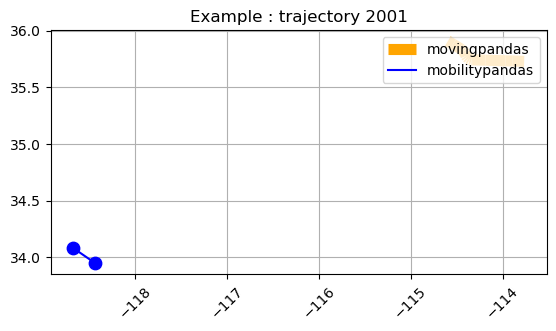

17 2
POINT (-113.76508712768555 35.72808837890625) POINT (-118.43144008091517 33.94725036621094)
POINT (-113.76508712768555 35.72808837890625) POINT (-118.43144008091517 33.94725036621094)

POINT (-114.59587584150597 35.90657896914725) POINT (-118.67071151733398 34.080893306408896)
POINT (-114.59587584150597 35.90657896914725) POINT (-118.67071151733398 34.080893306408896)


In [ ]:

# Plotting the trajectories
n=2001
# n=1010
simplified_without.trajectories[n].plot(color='orange', label='movingpandas', linewidth=8)
simplified_with2.values[n].plot(color='blue', label='mobilitypandas')
# simplified_with3.values[n].plot(color='green', label='mobilitypandas with from_arrays')
plt.title("Example : trajectory {0}".format(n))
plt.legend()
plt.show()


print(simplified_without.trajectories[n].size(), simplified_with2.values[n].num_instants())
print(trajectories_without.trajectories[n].get_start_location(), trajectories_with2.trajectory[n].start_value())
print(simplified_without.trajectories[n].get_start_location(), simplified_with2.values[n].start_value())
print()
print(trajectories_without.trajectories[n].get_end_location(), trajectories_with2.trajectory[n].end_value())
print(simplified_without.trajectories[n].get_end_location(), simplified_with2.values[n].end_value())


## Visualisation

In [ ]:
# results_bricolage = {
#     'extraction': (3.92, 325.73),
#     'construction_without': (8.60, 147.10),
#     'construction_from_instants': (29.48, 306.91),
#     'construction_from_arrays': (5.77, 2.11),
#     'simplify_without': (23.32, 0.78),
#     'simplify_with': (0.14, 0.00),
#     'simplify_sync': (0.03, 0.00)
# }

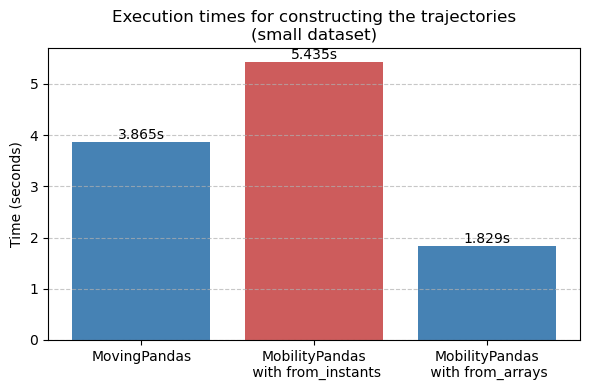

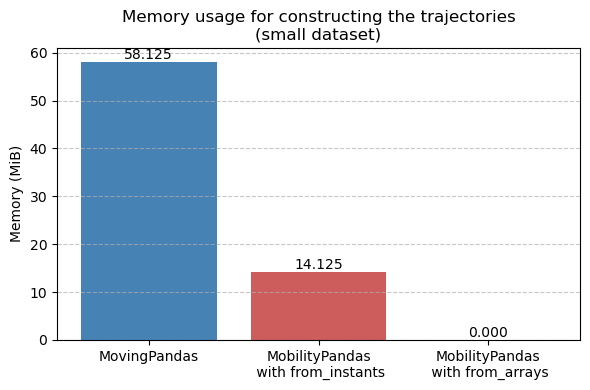

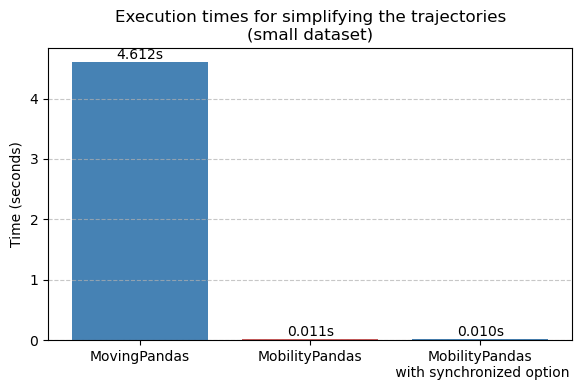

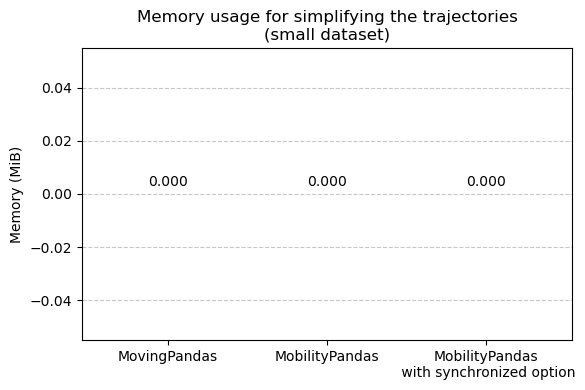

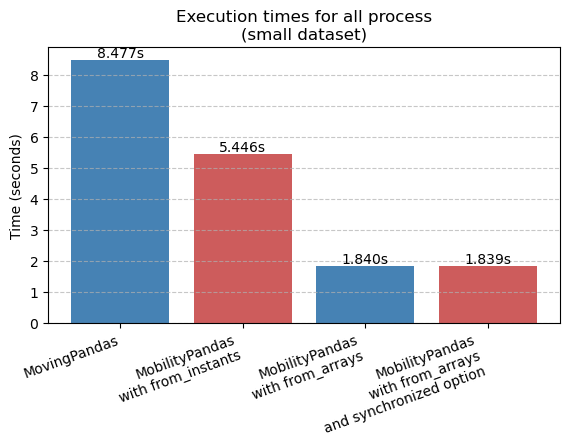

In [ ]:

# Construction
timesCo = [results['extraction'][0] + results['construction_without'][0], results['extraction'][0]+ results['construction_from_instants'][0], 
         results['extraction'][0]+ results['construction_from_arrays'][0]]
memCo = [results['construction_without'][1], results['construction_from_instants'][1], results['construction_from_arrays'][1]]
libs = ['MovingPandas', 'MobilityPandas\n with from_instants', 'MobilityPandas\n with from_arrays']


plt.figure(figsize=(6, 4))
bars = plt.bar(libs, timesCo, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}s", ha='center', va='bottom')

plt.title(f"Execution times for constructing the trajectories\n({chosen_size} dataset)")
plt.ylabel("Time (seconds)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
bars = plt.bar(libs, memCo, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}", ha='center', va='bottom')

plt.title(f"Memory usage for constructing the trajectories\n({chosen_size} dataset)")
plt.ylabel("Memory (MiB)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#Calculation
timesCa = [results['simplify_without'][0], results['simplify_with'][0], results['simplify_sync'][0]]
memCa = [results['simplify_without'][1], results['simplify_with'][1], results['simplify_sync'][1]]
libsCa = ['MovingPandas', 'MobilityPandas', 'MobilityPandas\n with synchronized option']

plt.figure(figsize=(6, 4))
bars = plt.bar(libsCa, timesCa, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}s", ha='center', va='bottom')

plt.title(f"Execution times for simplifying the trajectories\n({chosen_size} dataset)")
plt.ylabel("Time (seconds)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
bars = plt.bar(libsCa, memCa, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}", ha='center', va='bottom')

plt.title(f"Memory usage for simplifying the trajectories\n({chosen_size} dataset)")
plt.ylabel("Memory (MiB)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Total
times = [results['extraction'][0] + results['construction_without'][0] + results['simplify_without'][0], 
         results['extraction'][0]+ results['construction_from_instants'][0] + results['simplify_with'][0], 
         results['extraction'][0]+ results['construction_from_arrays'][0] + results['simplify_with'][0],
         results['extraction'][0]+ results['construction_from_arrays'][0] + results['simplify_sync'][0]]

libs = ['MovingPandas', 'MobilityPandas\n with from_instants', 'MobilityPandas\n with from_arrays', 
        'MobilityPandas\n with from_arrays\nand synchronized option']

plt.figure(figsize=(6, 4))
bars = plt.bar(libs, times, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}s", ha='center', va='bottom')

plt.title(f"Execution times for all process\n({chosen_size} dataset)")
plt.ylabel("Time (seconds)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.xticks(rotation=20, ha='right')
plt.show()
